# **RNN**

A type of sequential model to work specifically on sequential data. Mostly used in NLP.


A **Recurrent Neural Network (RNN)** is a class of artificial neural networks designed to process sequential data (such as time series, text sentences, or audio waveforms). 

Unlike standard feedforward networks that assume all inputs and outputs are independent, RNNs retain a **hidden state (memory)** that stores information about previous time steps.


When se send input to the RNN they are in format of `(batch_size, timesteps, input-features)`
- `timesteps` --  length of the sequence (how many historical points in time you look at)
- `input-features` -- the size of the information vector at a single point in time

**IMP**
In NLP based data inputs are sent word by word not by sentence, but in case of Time Series based data, inputs are sent by measurements at a specific intervals of time (for eg. hourly weather record, or daily stock prices).

**Inputs during NLP based data**

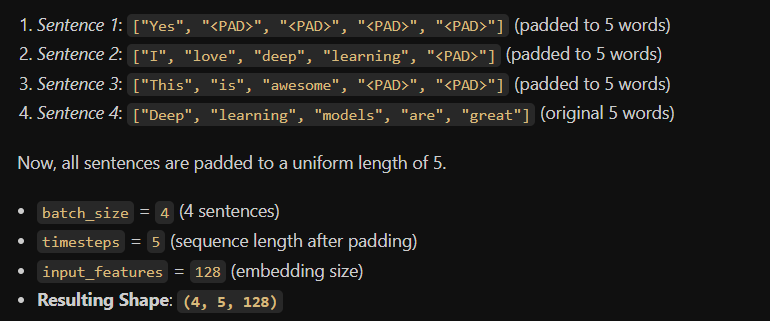

**Inputs during Time Series based data**

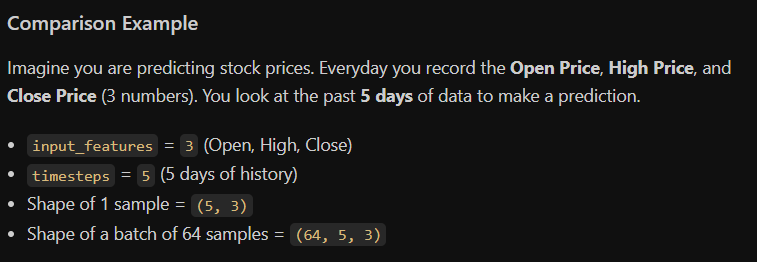




## The Core Concept

An RNN processes sequences step-by-step. At each time step $t$:
1. It takes the **current input** $x_t$.
2. It takes the **previous hidden state** $h_{t-1}$ (the memory of what happened before).
3. It combines them to compute the **new hidden state** $h_t$ and output $y_t$.

```mermaid
graph LR
    xt["Current Input (x_t)"] --> cell["RNN Cell"]
    ht_prev["Previous Memory (h_t-1)"] --> cell
    cell --> ht["Updated Memory (h_t)"]
    cell --> yt["Current Output (y_t)"]
    
    style cell fill:#f9f,stroke:#333,stroke-width:2px
```


## Mathematical Equations

The state updates at time step $t$ are calculated using the following formulas:

### 1. Hidden State Update
$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$$

Where:
*   $h_t$: New hidden state vector at step $t$
*   $h_{t-1}$: Previous hidden state vector at step $t-1$
*   $x_t$: Input vector at step $t$
*   $W_{hh}$: Weight matrix for hidden-to-hidden transitions (recurrent weights)
*   $W_{xh}$: Weight matrix for input-to-hidden transitions
*   $b_h$: Bias vector for the hidden state
*   $\tanh$: Hyperbolic tangent activation function (scales values between $-1$ and $1$)

### 2. Output Calculation
$$y_t = \text{softmax}(W_{hy} h_t + b_y)$$

Where:
*   $y_t$: Output prediction vector at step $t$
*   $W_{hy}$: Weight matrix mapping the hidden state to output space
*   $b_y$: Bias vector for the output


## Sequential Workflows

RNNs can be structured in several ways depending on the task:

*   **One-to-Many**: One input yields a sequence of outputs (e.g., Image Captioning: Image $\rightarrow$ Sentence).
*   **Many-to-One**: A sequence of inputs yields one output (e.g., Sentiment Classification: Sentence $\rightarrow$ Positive/Negative).
*   **Many-to-Many**: A sequence of inputs yields a sequence of outputs (e.g., Translation: English Sentence $\rightarrow$ Spanish Sentence).


## Major Limitations

Standard RNNs struggle with long sequences due to:
*   **Vanishing Gradients**: As gradients are backpropagated through time, multiplying many small weights repeatedly causes the gradient to shrink to zero. The model "forgets" things that happened early in the sequence.
*   **Exploding Gradients**: The opposite problem, where gradients grow exponentially, causing weights to oscillate or become `NaN`.

*Solutions*: Modern architectures like **LSTMs (Long Short-Term Memory)** and **GRUs (Gated Recurrent Units)** introduce gates to control what information to remember or forget, resolving the vanishing gradient problem.


## Simple Keras Implementation

Here is how to define a basic sequence classification RNN model in Keras:

```python
import keras
from keras import layers, Sequential

model = Sequential([
    layers.SimpleRNN(64, input_shape=(None, 10)),
    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)
```

---

## **Tell me what was the requirement for RNN, couldn't we have used ANN, or CNN ???**

When processing sequential data (like text sentences, time series, or audio), standard feedforward architectures like Artificial Neural Networks (ANNs) and Convolutional Neural Networks (CNNs) have structural limitations.

We cant use ANN and CNN coz :
- Variable input size from text based data
    - Loss of semantic meanings
- Dont remember the memory from the past data

#### **1. Limitations of ANNs (Dense Networks)**
*   **Fixed-Size Inputs**: An ANN requires a fixed number of input features (e.g., exactly 100 input nodes). However, sequential data naturally varies in length (a sentence can be 3 words or 30 words).
*   **No Temporal Order**: ANNs assume all input features are independent of one another. In sequential data, the order is critical. For example:
    *   *Sentence 1*: "The dog chased the cat."
    *   *Sentence 2*: "The cat chased the dog."
    An ANN treats the words as a bag of independent features and struggles to learn how the word order changes the meaning because it lacks a memory mechanism.

#### **2. Limitations of CNNs (Convolutional Networks)**
*   **Localized Receptive Fields**: A convolution layer only looks at a small local window (e.g., $3 \times 3$ or $5 \times 5$). It cannot easily model relationships between elements that are far apart in a sequence.
*   **No Sequential State**: CNNs do not maintain a running memory (hidden state) that updates over time; they are feedforward only.

#### **3. Why RNNs Solve These Problems**
Recurrent Neural Networks (RNNs) introduce three capabilities designed specifically for sequential workflows:

*   **Hidden State (Temporal Memory)**: An RNN processes inputs one step at a time in a loop. At each step, it combines the current input $x_t$ with its hidden state $h_{t-1}$ (the memory of previous steps) to compute the new state $h_t$.
*   **Variable-Length Sequences**: Because the model runs in a loop, it can process sequences of any length (from 1 step to thousands of steps) without changing the network's structure.
*   **Weight Sharing Across Time**: The network uses the exact same weight matrices ($W_{hh}$ and $W_{xh}$) at every time step, allowing it to recognize a pattern no matter where it occurs in the sequence.


| Feature | ANN (Dense) | CNN (Convolutional) | RNN (Recurrent) |
| :--- | :--- | :--- | :--- |
| **Input Size** | Fixed | Fixed (per dimension) | Variable (any sequence length) |
| **Data Assumption** | Independent inputs | Spatial local patterns | Sequential/Temporal dependencies |
| **Memory** | None | None | Hidden State ($h_t$) |
| **Best Used For** | Tabular data, simple mapping | Images, spatial patterns | Text, audio, time-series |

---
---

### PROS OF RNNs:
- **Handles Sequential Data**: Designed to capture patterns over time (text, audio, time-series, video).
- **Variable-Length Inputs**: Can process sequences of any length without changes to the architecture.
- **Parameter Sharing**: Reuses the same weight matrices at every time step, keeping the model size compact.
- **Historical Context**: Hidden state acts as memory to retain information from previous steps.

### CONS OF RNNs:
- **Sequential Processing**: Calculations cannot be run in parallel, making training slow on large datasets.
- **Vanishing/Exploding Gradients**: Gradients shrink to zero or grow to infinity during backpropagation over long sequences. 
    - Training gets stagnated during vanishing gradients.
    - Unstable training due to exploding gradients.
- **Short-Term Memory**: Standard cells lose context after 10-20 steps (LSTMs and GRUs extend this but still have limits).
- **High Memory Cost**: Must store all intermediate states across all steps during training.
- **Probelm of long term dependency on previous step data**: If the number of timesteps are too long then, the model will not be able to properly remember the previous step data.



### WHEN TO USE RNNs:
- **Order Matte**rs: Use when the meaning of the data depends strictly on the sequence order (e.g., text syntax, audio waveforms).
- **Dynamic Lengths**: Use when input sequences have different lengths (e.g., sentences of 5 words versus 50 words).
- **Real-time Step Predictions**: Use when you need a prediction at every time step as the sequence arrives.

### WHERE TO USE RNNs (APPLICATIONS):
- **Natural Language Processing**: Sentiment analysis, text classification, part-of-speech tagging, named entity recognition.
- **Speech Processing**: Voice commands, speech-to-text transcription, text-to-speech synthesis.
- **Time-Series Analysis**: Stock market forecasting, weather prediction, sensor data anomaly detection.
- **Video Processing**: Activity recognition, object tracking frame-by-frame.